### 1-(a) Total Least Squares Line Fitting

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Load data
D = np.genfromtxt("lines.csv", delimiter=",", skip_header=1)

# ---------- TLS Function ----------
def fit_tls(points):
    centroid = np.mean(points, axis=0)
    X = points - centroid

    U, S, Vt = np.linalg.svd(X)
    direction = Vt[0]

    # normal vector
    a = -direction[1]
    b = direction[0]
    c = -(a * centroid[0] + b * centroid[1])

    # normalize
    norm = np.sqrt(a*a + b*b)
    a, b, c = a/norm, b/norm, c/norm

    if b < 0:
        a, b, c = -a, -b, -c

    m = -a / b
    k = -c / b

    return a, b, c, m, k


Q1(a) TLS Line:
ax + by + c = 0 : -0.7736x + 0.6337y + 3.7942 = 0
y = mx + k       : y = 1.2207x + -5.9872


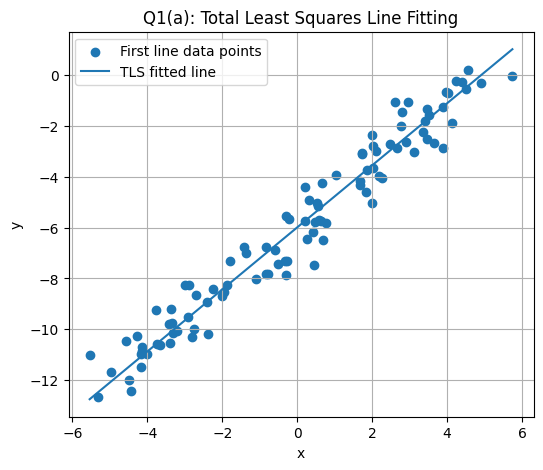

In [6]:
# =========================
# Q1(a) TLS for first line
# =========================
x1 = D[:, 0]
y1 = D[:, 3]

points1 = np.vstack((x1, y1)).T
a, b, c, m, k = fit_tls(points1)

print("Q1(a) TLS Line:")
print(f"ax + by + c = 0 : {a:.4f}x + {b:.4f}y + {c:.4f} = 0")
print(f"y = mx + k       : y = {m:.4f}x + {k:.4f}")

# Plot Q1(a)
xx = np.linspace(min(x1), max(x1), 100)
yy = m * xx + k

plt.figure(figsize=(6, 5))
plt.scatter(x1, y1, label="First line data points")
plt.plot(xx, yy, label="TLS fitted line")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Q1(a): Total Least Squares Line Fitting")
plt.legend()
plt.grid(True)
plt.show()



Q1(b) RANSAC Detected Lines:
Line 1:
  ax + by + c = 0 : 0.4396x + 0.8982y + -1.8679 = 0
  y = mx + k       : y = -0.4894x + 2.0797
Line 2:
  ax + by + c = 0 : -0.7319x + 0.6815y + -0.7588 = 0
  y = mx + k       : y = 1.0740x + 1.1135
Line 3:
  ax + by + c = 0 : -0.7869x + 0.6171y + 3.5130 = 0
  y = mx + k       : y = 1.2751x + -5.6927


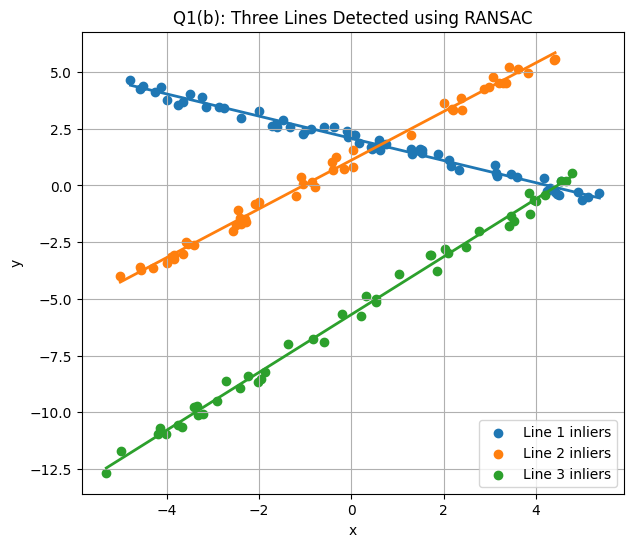

In [9]:
# =========================
# Q1(b) RANSAC for 3 lines
# =========================
X_cols = D[:, :3]
Y_cols = D[:, 3:]

X_all = X_cols.flatten()
Y_all = Y_cols.flatten()

all_points = np.vstack((X_all, Y_all)).T


def line_from_two_points(p1, p2):
    a = p1[1] - p2[1]
    b = p2[0] - p1[0]
    c = p1[0] * p2[1] - p2[0] * p1[1]

    norm = np.sqrt(a*a + b*b)
    if norm == 0:
        return None

    return np.array([a/norm, b/norm, c/norm])


def ransac_line(points, iterations=2000, threshold=0.30):
    best_inliers = []
    best_line = None

    n = len(points)

    for i in range(iterations):
        ids = np.random.choice(n, 2, replace=False)
        p1 = points[ids[0]]
        p2 = points[ids[1]]

        line = line_from_two_points(p1, p2)
        if line is None:
            continue

        distances = np.abs(points @ line[:2] + line[2])
        inliers = np.where(distances < threshold)[0]

        if len(inliers) > len(best_inliers):
            best_inliers = inliers
            best_line = line

    # Refit using TLS on best inliers
    inlier_points = points[best_inliers]
    a, b, c, m, k = fit_tls(inlier_points)

    return np.array([a, b, c]), inlier_points


remaining_points = all_points.copy()
detected_lines = []
detected_inliers = []

for i in range(3):
    line, inlier_points = ransac_line(remaining_points)

    a, b, c = line
    m = -a / b
    k = -c / b

    detected_lines.append((a, b, c, m, k))
    detected_inliers.append(inlier_points)

    # Remove inliers
    distances = np.abs(remaining_points @ line[:2] + line[2])
    remaining_points = remaining_points[distances >= 0.30]

print("\nQ1(b) RANSAC Detected Lines:")
for i, (a, b, c, m, k) in enumerate(detected_lines, start=1):
    print(f"Line {i}:")
    print(f"  ax + by + c = 0 : {a:.4f}x + {b:.4f}y + {c:.4f} = 0")
    print(f"  y = mx + k       : y = {m:.4f}x + {k:.4f}")


# Plot Q1(b)
plt.figure(figsize=(7, 6))

for i, inliers in enumerate(detected_inliers):
    plt.scatter(inliers[:, 0], inliers[:, 1], label=f"Line {i+1} inliers")

    a, b, c, m, k = detected_lines[i]
    xx = np.linspace(min(inliers[:, 0]), max(inliers[:, 0]), 100)
    yy = m * xx + k
    plt.plot(xx, yy, linewidth=2)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Q1(b): Three Lines Detected using RANSAC")
plt.legend()
plt.grid(True)
plt.show()